# 말벌 포함 여부 이진분류 학습 — 원본 데이터 baseline

- non_wasp=0: 말벌이 없는 꿀벌/환경음. wasp=1: 말벌 단독 또는 말벌 포함 혼합음.
- 합성 혼합 augmentation 없이 라벨이 확인된 원본 WAV만 학습합니다.
- 데이터 배치: `audio/<클래스>/<원본ID>/*.wav` (라벨을 확인한 2초 이하 구간).
- 학습 전에 데이터 개수, source 분할 및 필수 점검 셀을 확인하세요.
- 원본ID 분할은 파일명만으로 독립성을 보장하지 않습니다. 실제 녹음 출처를 확인해야 합니다.
- `src/`의 공통 전처리·추론 코드는 별도 파일이며 이 노트북에 포함되어 있지 않습니다.
- 새 모델은 `models/`에 저장됩니다.
- 커널 재시작 후 위에서부터 실행. 임계값 변경 시 평가도 다시 실행하세요.


In [1]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
! pip install numpy pandas matplotlib seaborn librosa pillow scikit-learn tensorflow image lightgbm xgboost

In [3]:
%pip list

Package                   Version
------------------------- ------------
absl-py                   2.5.0
aiohappyeyeballs          2.7.1
aiohttp                   3.14.3
aiosignal                 1.4.0
annotated-doc             0.0.5
annotated-types           0.8.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
asgiref                   3.12.1
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.3.0
async-timeout             5.0.1
attrs                     26.1.0
audioread                 3.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
branca                    0.8.2
brotlicffi                1.2.0.0
certifi                   2026.7.22
cffi                      2.1.0
charset-normalizer        3.4.7
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler           

# 1. 환경 설정

In [4]:
# 저장소 루트 또는 ai_model에서 실행 가능
import sys
from pathlib import Path
notebook_root = Path.cwd() if (Path.cwd() / 'src' / 'config.py').is_file() else Path.cwd() / 'ai_model'
if not (notebook_root / 'src' / 'config.py').is_file():
    raise RuntimeError('Buzz 또는 ai_model 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(notebook_root))
import os                           # 폴더 / 파일 경로 처리
import glob                         # 특정 패턴의 파일 검색 (예: .wav .mp3 등)
import random                       # 랜덤 샘플 선택

import numpy as np                  # 오디오 파형, 행렬 계산
import pandas as pd                 # 데이터프레임
import matplotlib.pyplot as plt     # 그래프 (시각화)
import seaborn as sns               # confusion matrix 등 시각화
%matplotlib inline

import librosa                      # wav 로딩, waveform, FFT/STFT, Mel Spectrogram, MFCC 등 대부분 처리
import librosa.display

import joblib

from sklearn.metrics import (       # 모델 성능 평가
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 머신러닝 3종
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 분할
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 딥러닝 (CNN, CRNN, MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

In [5]:
# 학습과 추론이 같은 클래스 순서, 전처리, 저장 경로를 사용한다.
from src.config import (
    BASE_DIR, AUDIO_DIR, MODEL_DIR, CLASSES, WASP_INDEX, WASP_THRESHOLD,
    SR, DURATION, SAMPLES_PER_TRACK, TARGET_DB,
    IMG_HEIGHT, IMG_WIDTH, N_FFT, HOP_LENGTH, N_MELS,
)
from src.binary_classification import predict_classes, ordered_ml_probabilities
from src.dataset import collect_audio_files, split_by_source
from src.evaluation_reporting import (
    save_validation_report, save_training_histories, save_prediction_manifest,
    save_source_report, save_confusion_matrix,
)

BATCH_SIZE = 16
EPOCHS = 50
print('Classes:', dict(enumerate(CLASSES)))
print('Audio:', AUDIO_DIR)
print('Binary models:', MODEL_DIR)
print('Wasp threshold:', WASP_THRESHOLD)

Classes: {0: 'non_wasp', 1: 'wasp'}
Audio: C:\Users\gold4\Desktop\Buzz\ai_model\audio
Binary models: C:\Users\gold4\Desktop\Buzz\ai_model\models
Wasp threshold: 0.5


# 2. 데이터셋 확인 및 기본 유틸리티

In [6]:
def ensure_directory_exists(dir_path):
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# audio/non_wasp/<원본ID>/*.wav, audio/wasp/<원본ID>/*.wav
# 말벌 단독/혼합 모두 wasp. 2초 이하로 잘라 구간별 라벨을 확인한다.
records = collect_audio_files(AUDIO_DIR)

,Class,Count,Ratio
0,non_wasp,4006,0.563036
1,wasp,3109,0.436964


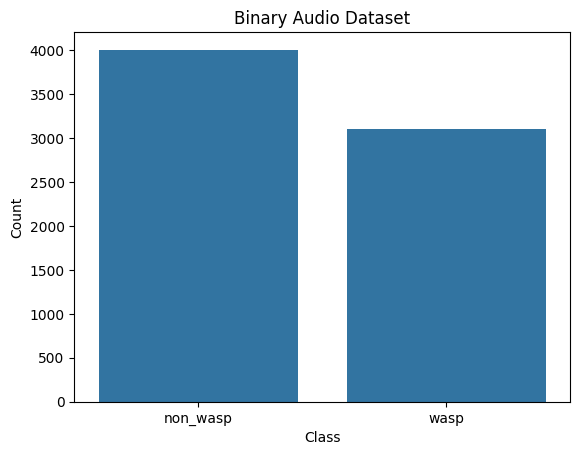

In [7]:
file_counts = {cls: sum(row['label'] == i for row in records) for i, cls in enumerate(CLASSES)}
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=['Class', 'Count'])
file_counts_df['Ratio'] = file_counts_df['Count'] / file_counts_df['Count'].sum()
display(file_counts_df)
sns.barplot(data=file_counts_df, x='Class', y='Count')
plt.title('Binary Audio Dataset')
plt.show()

# 3. 오디오 전처리 및 EDA

In [8]:
from src.audio_preprocessing import load_audio_file, normalize_rms
# 랜덤 crop 없이 학습과 추론에서 동일한 2초 전처리를 사용한다.


In [9]:
sample_files = {
    cls: next(row['path'] for row in records if row['label'] == i)
    for i, cls in enumerate(CLASSES)
}
for cls, audio_path in sample_files.items():
    y_sample, sr_sample = load_audio_file(audio_path)
    print(cls, audio_path, sr_sample, len(y_sample))

non_wasp C:\Users\gold4\Desktop\Buzz\ai_model\audio\non_wasp\01_1_SW_20221114\clip_0000.wav 24000 48000
wasp C:\Users\gold4\Desktop\Buzz\ai_model\audio\wasp\01_1_SW_20221118\clip_0017.wav 24000 48000


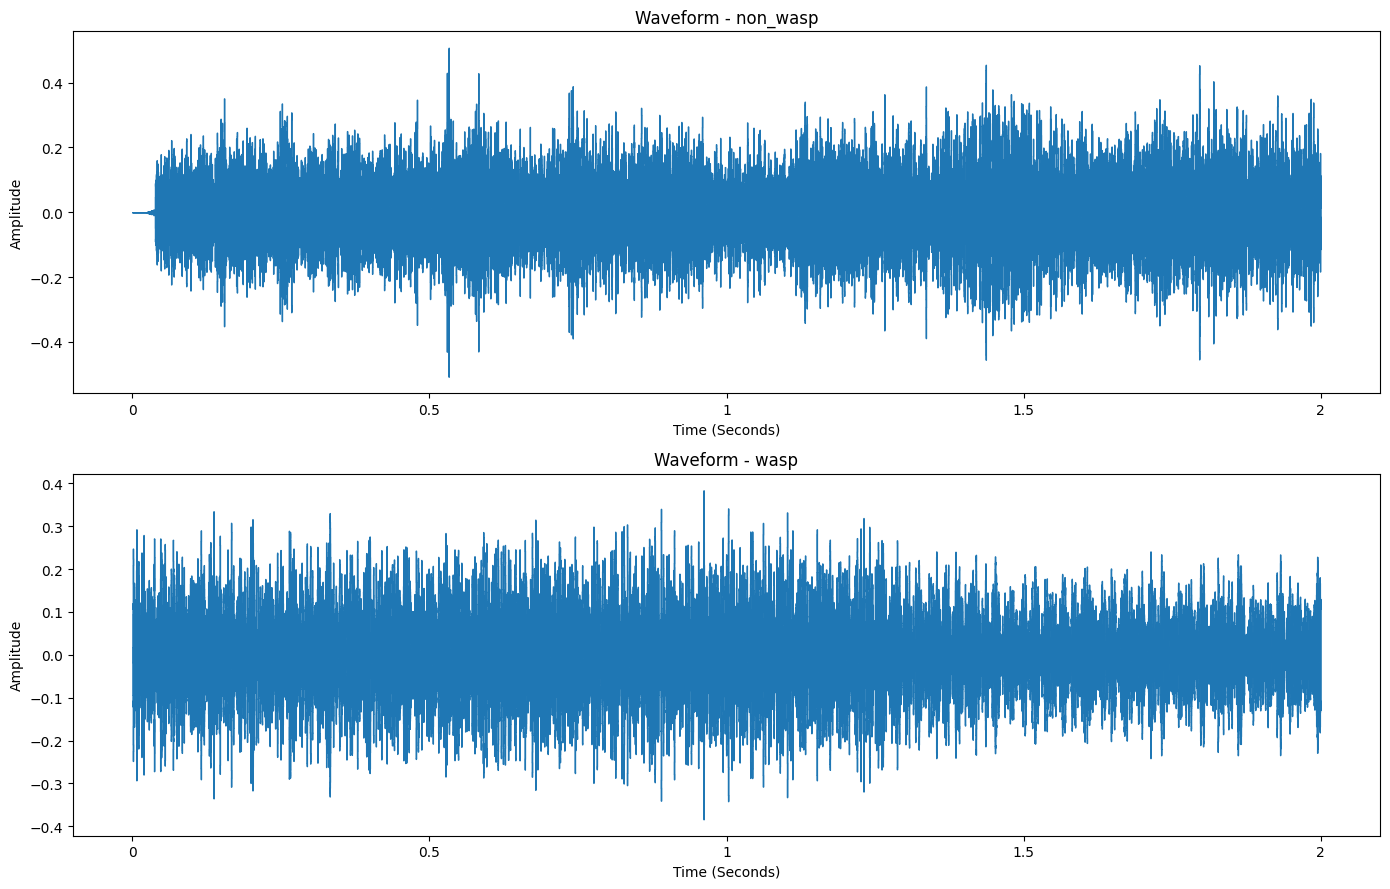

In [10]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    plt.subplot(len(CLASSES), 1, i)

    librosa.display.waveshow(y_sample, sr = sr_sample)

    plt.title(f'Waveform - {cls}')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

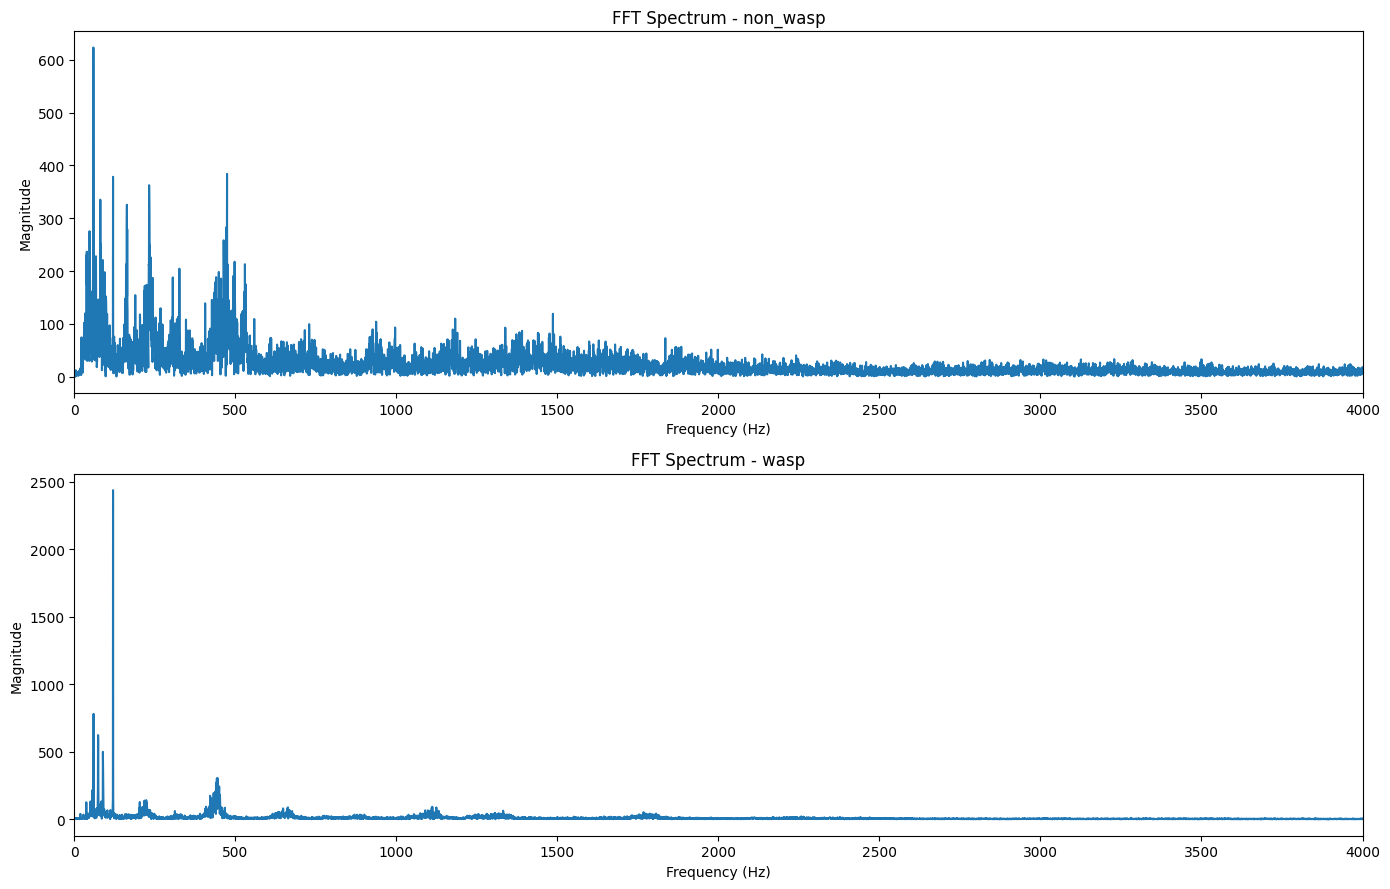

In [11]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # 실수 Audio 신호용 FFT
    fft_sample = np.fft.rfft(y_sample)

    # Magnitude Spectrum
    magnitude_sample = np.abs(fft_sample)

    # Frequency Axis
    freqs_sample = np.fft.rfftfreq(len(y_sample), d = 1 / sr_sample)

    plt.subplot(len(CLASSES), 1, i)

    plt.plot(freqs_sample, magnitude_sample)

    plt.title(f'FFT Spectrum - {cls}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    plt.xlim(0, sr_sample / 6)

plt.tight_layout()
plt.show()

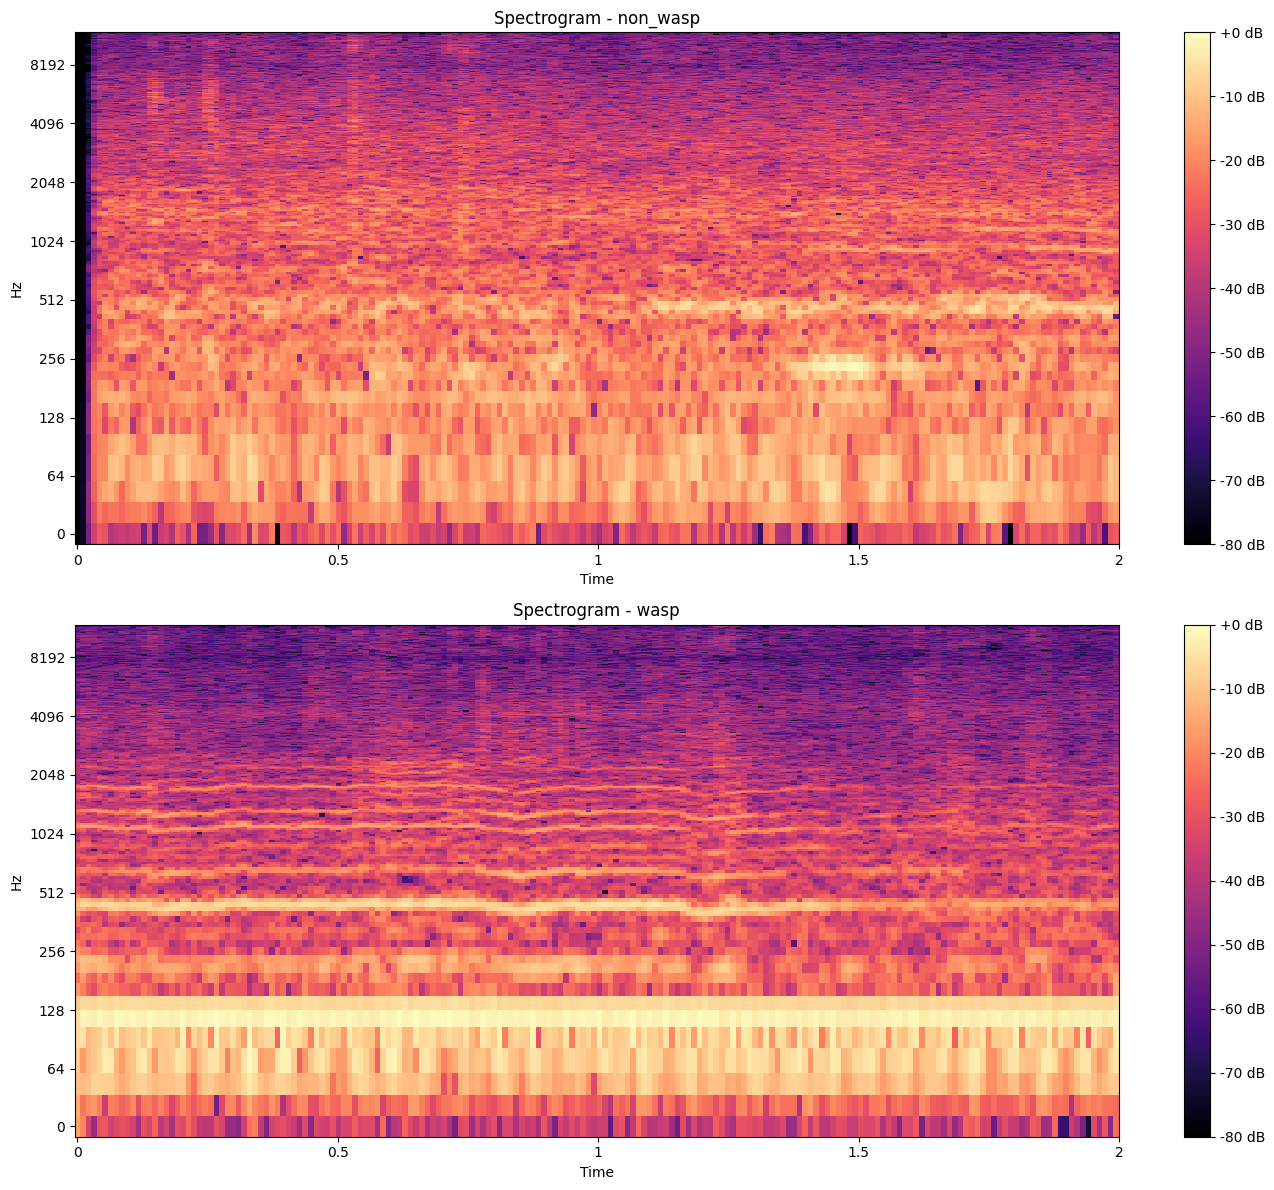

In [12]:
plt.figure(figsize = (14, 12))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # STFT
    stft_sample = librosa.stft(y_sample, n_fft = N_FFT, hop_length = HOP_LENGTH)

    # Magnitude Spectrogram
    spectrogram_sample = np.abs(stft_sample)

    # dB 변환
    spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref = np.max)

    plt.subplot(len(CLASSES), 1, i)

    img = librosa.display.specshow(
        spectrogram_db_sample,
        sr = sr_sample,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log',
        cmap = 'magma'
    )

    plt.colorbar(img, format = '%+2.0f dB')
    plt.title(f'Spectrogram - {cls}')

plt.tight_layout()
plt.show()

# 4. Deep Learning

## 4-1. Mel-Spectrogram 데이터셋 구성

In [13]:
from src.audio_preprocessing import create_mel_spectrogram_from_audio
from src.feature_extraction import extract_audio_features_from_audio

In [14]:
# 같은 파형에서 DL/ML 특징을 함께 생성하여 구간·라벨·순서를 일치시킨다.
mel_data, ml_features = [], []
for row in records:
    y_audio, sr_audio = load_audio_file(row['path'])
    mel_data.append(create_mel_spectrogram_from_audio(y_audio, sr_audio))
    ml_features.append(extract_audio_features_from_audio(y_audio, sr_audio))

X_mel = np.asarray(mel_data, dtype=np.float32)
y_mel = np.asarray([row['label'] for row in records], dtype=np.int32)
mel_file_paths = np.asarray([row['path'] for row in records])
source_ids = np.asarray([row['source_id'] for row in records])
X_ml = np.asarray(ml_features, dtype=np.float32)
y_ml = y_mel.copy()
ml_file_paths = mel_file_paths.copy()
print('Mel:', X_mel.shape, 'ML:', X_ml.shape, 'Labels:', y_mel.shape)

Mel: (7115, 128, 188) ML: (7115, 74) Labels: (7115,)


In [15]:
# 원본 영상/녹음 단위 분리. 같은 원본의 잘린 구간은 하나의 split에만 포함된다.
train_indices, val_indices, test_indices = split_by_source(y_mel, source_ids, seed=SEED)
X_train_mel, X_val_mel, X_test_mel = [X_mel[i] for i in (train_indices, val_indices, test_indices)]
y_train_mel, y_val_mel, y_test_mel = [y_mel[i] for i in (train_indices, val_indices, test_indices)]
paths_train_mel, paths_val_mel, paths_test_mel = [mel_file_paths[i] for i in (train_indices, val_indices, test_indices)]

# 학습 세트만으로 클래스 불균형 보정. 말벌=1을 양성으로 취급한다.
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)))
for name, indices in zip(('Train', 'Validation', 'Test'), (train_indices, val_indices, test_indices)):
    print(name, 'segments:', len(indices), 'sources:', len(set(source_ids[indices])),
          {cls: int(np.sum(y_mel[indices] == i)) for i, cls in enumerate(CLASSES)})

# 재현/누수 점검용 분할 목록 저장(음원은 이동하지 않는다).
ensure_directory_exists(MODEL_DIR)
split_rows = []
for name, indices in zip(('train', 'validation', 'test'), (train_indices, val_indices, test_indices)):
    for i in indices:
        split_rows.append({**records[i], 'split': name})
pd.DataFrame(split_rows).to_csv(MODEL_DIR / 'dataset_split.csv', index=False)

Train segments: 4885 sources: 84 {'non_wasp': 2749, 'wasp': 2136}
Validation segments: 1126 sources: 18 {'non_wasp': 645, 'wasp': 481}
Test segments: 1104 sources: 18 {'non_wasp': 612, 'wasp': 492}


### 원본 Train baseline
합성 혼합 없이 source 단위로 분리된 원본 Train 데이터만 사용합니다.


In [16]:
# ===== 원본 Train baseline =====
# 혼합 augmentation 없이 분할된 원본 특징과 라벨을 그대로 사용합니다.
X_train_mel = X_mel[train_indices].copy()
y_train_mel = y_mel[train_indices].copy()
original_train_counts = np.bincount(y_train_mel, minlength=2)
class_weights = dict(enumerate(
    compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)
))

print('원본 Train baseline:', X_train_mel.shape, {
    cls: int(original_train_counts[i]) for i, cls in enumerate(CLASSES)
})

원본 Train baseline: (4885, 128, 188) {'non_wasp': 2749, 'wasp': 2136}


In [17]:
# ===== 재학습 전 필수 점검 =====
# 원본 Train baseline과 source 단위 분할이 유지되는지 확인합니다.
assert len(X_train_mel) == len(y_train_mel) == len(train_indices)
assert len(X_val_mel) == len(y_val_mel) == len(val_indices)
assert len(X_test_mel) == len(y_test_mel) == len(test_indices)
np.testing.assert_array_equal(X_train_mel, X_mel[train_indices])
np.testing.assert_array_equal(y_train_mel, y_mel[train_indices])
np.testing.assert_array_equal(X_val_mel, X_mel[val_indices])
np.testing.assert_array_equal(y_val_mel, y_mel[val_indices])
np.testing.assert_array_equal(X_test_mel, X_mel[test_indices])
np.testing.assert_array_equal(y_test_mel, y_mel[test_indices])
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[val_indices]))
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[test_indices]))
assert not set(map(str, source_ids[val_indices])) & set(map(str, source_ids[test_indices]))
print('PASS: 원본 Train 사용 / 클래스별 개수 유지 / Validation·Test 불변 / source 분리')
print('주의: source_id가 실제 독립 녹음 단위인지와 라벨 정확성은 별도 검수가 필요합니다.')

PASS: 원본 Train 사용 / 클래스별 개수 유지 / Validation·Test 불변 / source 분리
주의: source_id가 실제 독립 녹음 단위인지와 라벨 정확성은 별도 검수가 필요합니다.


In [18]:
from src.audio_preprocessing import (
    prepare_cnn_dataset, prepare_mobilenet_dataset, prepare_crnn_dataset,
)

In [19]:
# CNN
X_train_cnn = prepare_cnn_dataset(X_train_mel)
X_val_cnn = prepare_cnn_dataset(X_val_mel)
X_test_cnn = prepare_cnn_dataset(X_test_mel)

# MobileNetV2
X_train_mobile = prepare_mobilenet_dataset(X_train_mel)
X_val_mobile = prepare_mobilenet_dataset(X_val_mel)
X_test_mobile = prepare_mobilenet_dataset(X_test_mel)

# CRNN
X_train_crnn = prepare_crnn_dataset(X_train_mel)
X_val_crnn = prepare_crnn_dataset(X_val_mel)
X_test_crnn = prepare_crnn_dataset(X_test_mel)

print('===== 딥러닝 입력 shape =====')
print('CNN : ', X_train_cnn.shape)
print('Mobile : ', X_train_mobile.shape)
print('CRNN : ', X_train_crnn.shape)

===== 딥러닝 입력 shape =====
CNN :  (4885, 128, 128, 1)
Mobile :  (4885, 128, 128, 3)
CRNN :  (4885, 128, 188, 1)


In [20]:
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASSES)
}

idx_to_class = {
    idx: cls
    for idx, cls in enumerate(CLASSES)
}

print('class_to_idx: ', class_to_idx)
print('idx_to_class: ', idx_to_class)

class_to_idx:  {'non_wasp': 0, 'wasp': 1}
idx_to_class:  {0: 'non_wasp', 1: 'wasp'}


## 4-2. CNN

Mel-Spectrogram을 입력으로 사용하는 CNN 분류 모델을 학습한다.

- 입력: 128 × 128 × 1 Mel-Spectrogram
- 출력 클래스: non_wasp / wasp
- 평가 지표: Accuracy, Precision, Recall, Macro F1, Wasp Recall
- 최적 모델은 Validation Loss 기준으로 저장

In [21]:
'''
Mel-Spectrogram 기반 CNN 분류 모델

- 입력 : 128 x 128 크기의 1채널 Mel-Spectrogram
- 출력 : non_wasp / wasp 2개 클래스 확률
'''

# CNN 입력 shape
cnn_input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

# CNN 모델 생성
cnn_model = models.Sequential([
    layers.Input(shape = cnn_input_shape),

    # 첫 번째 Convolution Layer
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution Layer
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution Layer
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 특징맵을 하나의 벡터로 축약
    layers.GlobalAveragePooling2D(),

    # 분류층
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(len(CLASSES), activation = 'softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,058 (394.76 KB)

 Trainable params: 101,058 (394.76 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
'''
CNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CNN 모델 저장 경로
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'cnn.keras')

# CNN 모델 컴파일
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
cnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Accuracy가 가장 높은 모델 저장
cnn_checkpoint = ModelCheckpoint(
    filepath = CNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CNN Model Path: ', CNN_MODEL_PATH)

CNN Model Path:  C:\Users\gold4\Desktop\Buzz\ai_model\models\cnn.keras


In [23]:
'''
CNN 모델 학습
'''

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_mel,
    validation_data = (X_val_cnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [cnn_early_stopping, cnn_checkpoint],
    verbose = 1
)

Epoch 1/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7282 - loss: 0.5125
Epoch 1: val_loss improved from None to 0.08423, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\cnn.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8514 - loss: 0.3436 - val_accuracy: 0.9796 - val_loss: 0.0842
Epoch 2/50
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9453 - loss: 0.1885
Epoch 2: val_loss improved from 0.08423 to 0.07034, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\cnn.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9484 - loss: 0.1767 - val_accuracy: 0.9822 - val_loss: 0.0703
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9609 - loss: 0.1342
Epoch 3: val_loss did not improve from 0.07034
306/306 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.9601 - loss: 0.1275 - val_accuracy: 0.9663 - val_loss: 0.1075
Epoch 4/50
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9643 - loss: 0.1142
Epoch 4

In [24]:
def plot_training_history(history, model_name):
    # 학습 정확도 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['accuracy'], label = 'Train Accuracy')
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CNN 학습 손실 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['loss'], label = 'Train Loss')
    plt.plot(history.history['val_loss'], label = 'Validation Loss')

    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
def evaluate_model(y_true, y_pred, model_name, show_report=True):
    # CLASSES 순서는 non_wasp=0, wasp=1. 미탐/오탐을 직접 집계한다.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Wasp Recall': recall_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'Wasp Precision': precision_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'False Negative': int(fn),
        'False Positive': int(fp),
        'Wasp Support': int(fn + tp),
        'Non Wasp Support': int(tn + fp),
        'False Positive Rate': float(fp / (fp + tn)) if fp + tn else 0.0,
    }
    if show_report:
        print(classification_report(y_true, y_pred, labels=[0, 1], target_names=CLASSES, zero_division=0))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        plt.title(f'{model_name} Binary Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        print(result)
    return result

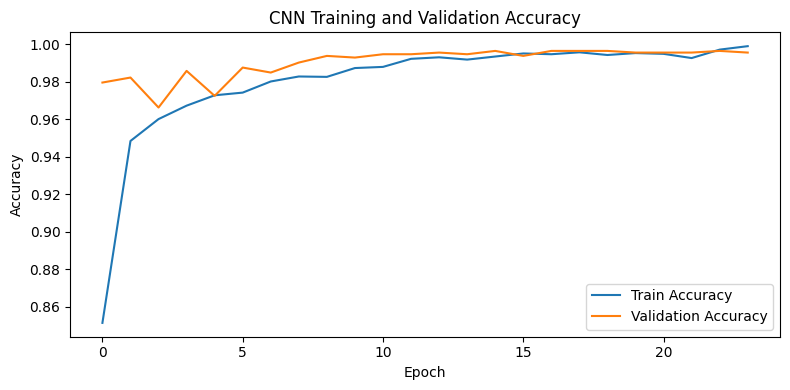

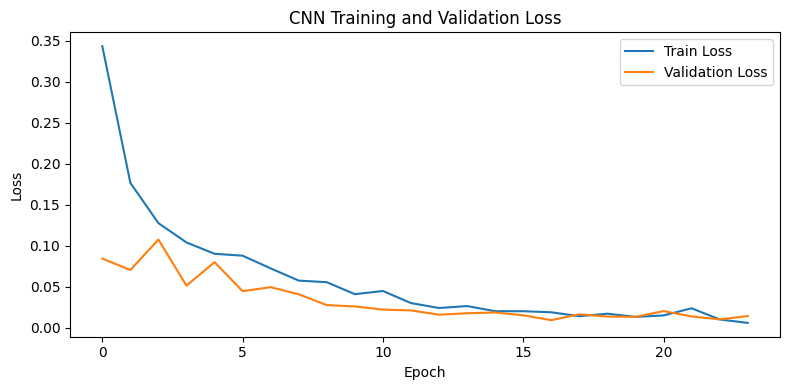

              precision    recall  f1-score   support

    non_wasp       1.00      1.00      1.00       645
        wasp       0.99      1.00      1.00       481

    accuracy                           1.00      1126
   macro avg       1.00      1.00      1.00      1126
weighted avg       1.00      1.00      1.00      1126



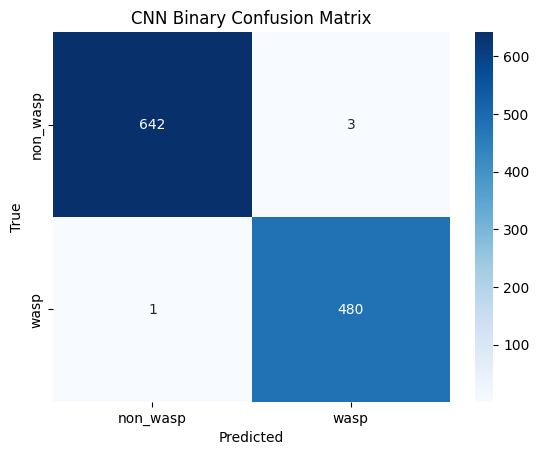

{'Model': 'CNN', 'Accuracy': 0.9964476021314387, 'Precision': 0.9961168049612164, 'Recall': 0.9966349175651501, 'Macro F1': 0.9963725161722636, 'Wasp Recall': 0.997920997920998, 'Wasp Precision': 0.9937888198757764, 'False Negative': 1, 'False Positive': 3, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.004651162790697674}


In [26]:
'''
CNN Validation 평가
'''

# 클래스별 확률을 예측
cnn_val_pred_probs = cnn_model.predict(X_val_cnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
cnn_val_pred_classes = predict_classes(cnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(cnn_history, 'CNN')

cnn_val_result = evaluate_model(y_val_mel, cnn_val_pred_classes, 'CNN')

## 4-3. MobileNetV2

사전 학습된 MobileNetV2 모델을 활용하여 Mel-Spectrogram을 분류한다

- 입력: 128 x 128 x 3 Mel-Spectrogram
- 출력 클래서: non_wasp / wasp
- ImageNet 사전 학습 가중치를 활용한 Transfer Learning 사용
- MobileNetV2의 기본 특징 추출층은 동결하여 학습
- CNN 모델과 동일한 Train / Val / Test 데이터를 사용

In [27]:
'''
Mel-Spectrogram 기반 MobileNetV2 분류 모델

- ImageNet으로 사전 학습된 MobileNetV2를 특징 추출기로 사용한다.
- 데이터셋이 작기 때문에 기본 MobileNetV2 층은 동결한다.
- 마지막 분류층만 non_wasp / wasp 분류에 맞게 새로 학습한다.
'''

# MobileNetV2 입력 shape
mobilenet_input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 사전 학습된 MobileNetV2 불러오기
mobilenet_base = MobileNetV2(
    input_shape = mobilenet_input_shape,
    include_top = False,
    weights = 'imagenet'
)

# 사전 학습된 특징 추출층 동결
mobilenet_base.trainable = False

# 분류 모델 구성
mobilenet_model = models.Sequential([
    layers.Input(shape = mobilenet_input_shape),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    layers.Dense(len(CLASSES), activation = 'softmax')
])

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
'''
MobileNetV2 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# MobileNetV2 모델 저장 경로
MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'mobilenetv2.keras')

# Model Compile
mobilenet_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
mobilenet_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
mobilenet_checkpoint = ModelCheckpoint(
    filepath = MOBILENET_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('MobileNetV2 Model Path: ', MOBILENET_MODEL_PATH)

MobileNetV2 Model Path:  C:\Users\gold4\Desktop\Buzz\ai_model\models\mobilenetv2.keras


In [29]:
'''
MobileNetV2 학습
'''

mobilenet_history = mobilenet_model.fit(
    X_train_mobile,
    y_train_mel,
    validation_data = (X_val_mobile, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [mobilenet_early_stopping, mobilenet_checkpoint],
    verbose = 1
)

Epoch 1/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9323 - loss: 0.1688
Epoch 1: val_loss improved from None to 0.05020, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\mobilenetv2.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 133s 417ms/step - accuracy: 0.9720 - loss: 0.0833 - val_accuracy: 0.9867 - val_loss: 0.0502
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9940 - loss: 0.0247
Epoch 2: val_loss improved from 0.05020 to 0.02480, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\mobilenetv2.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 127s 367ms/step - accuracy: 0.9926 - loss: 0.0249 - val_accuracy: 0.9911 - val_loss: 0.0248
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9887 - loss: 0.0276
Epoch 3: val_loss improved from 0.02480 to 0.02404, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\mobilenetv2.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 140s 360ms/step - accuracy: 0.9912 - loss: 0.0219 - val_accuracy: 0.9911 - val

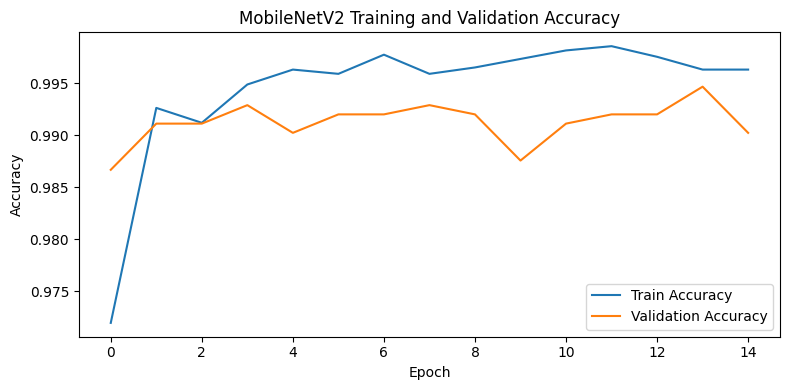

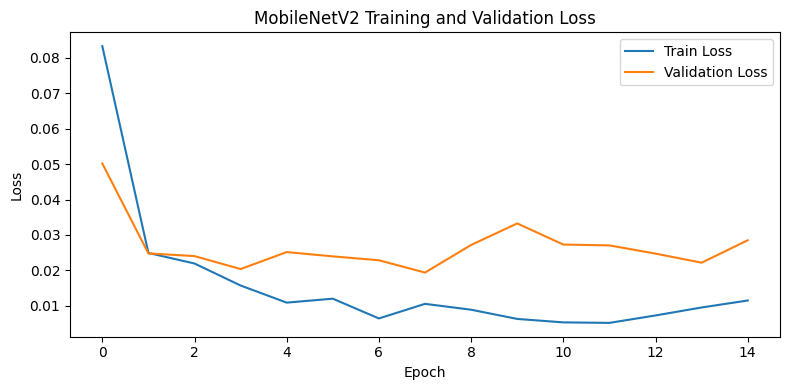

              precision    recall  f1-score   support

    non_wasp       0.99      0.99      0.99       645
        wasp       0.99      0.99      0.99       481

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



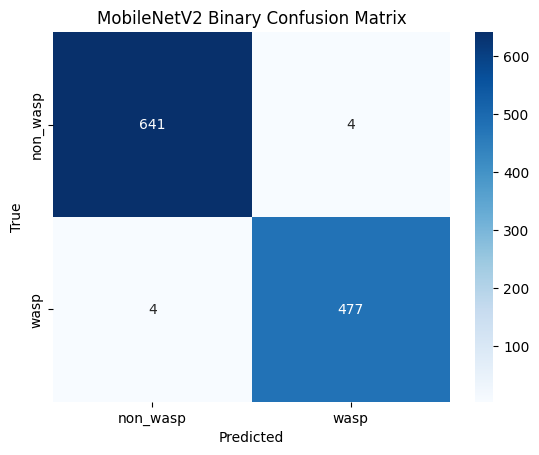

{'Model': 'MobileNetV2', 'Accuracy': 0.9928952042628775, 'Precision': 0.9927412206481974, 'Recall': 0.9927412206481974, 'Macro F1': 0.9927412206481974, 'Wasp Recall': 0.9916839916839917, 'Wasp Precision': 0.9916839916839917, 'False Negative': 4, 'False Positive': 4, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.006201550387596899}


In [30]:
'''
MobileNetV2 Validation 평가
'''

# 클래스 별 확률 예측
mobilenet_val_pred_probs = mobilenet_model.predict(X_val_mobile, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
mobilenet_val_pred_classes = predict_classes(mobilenet_val_pred_probs, WASP_THRESHOLD)

plot_training_history(mobilenet_history, 'MobileNetV2')

mobilenet_val_result = evaluate_model(y_val_mel, mobilenet_val_pred_classes, 'MobileNetV2')

## 4-4. CRNN

Mel-Spectrogram의 공간적 특징과 시간적 변화를 함께 학습하기 위해 CNN과 RNN을 결합한 CRNN 모델을 구성한다.

- CNN을 통해 주파수 패턴의 특징을 추출
- RNN(GRU)을 통해 시간에 따른 특징 변화를 학습
- 출력 클래스: non_wasp / wasp
- CNN, MobileNetV2와 동일한 Train / Val / Test 데이터 사용

In [31]:
'''
Mel-Spectrogram 기반 CRNN 분류 모델

- CNN으로 Mel-Spectrogram의 주요 특징을 추출한다.
- GRU를 사용하여 시간에 따른 특징 변화를 학습한다.
- non_wasp / wasp 2개 클래스를 분류한다.
'''

# CRNN 입력 shape
crnn_input_shape = X_train_crnn.shape[1:]

# 입력층
crnn_input = layers.Input(shape = crnn_input_shape)

# =========================
# CNN Feature 추출
# =========================

x = layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(crnn_input)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

# =========================
# CNN → RNN 형태 변환
# =========================

# 현재 CNN 출력 shape에서 시간 축을 sequence로 사용하도록 변환
shape = x.shape

x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Dense(128, activation = 'relu')(x)

# =========================
# GRU
# =========================

x = layers.GRU(64)(x)

# =========================
# Classification
# =========================

x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

crnn_output = layers.Dense(len(CLASSES), activation = 'softmax')(x)
crnn_model = models.Model(inputs = crnn_input, outputs = crnn_output)

crnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 188, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 188, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 47, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47, 128)        │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,626 (1.23 MB)

 Trainable params: 322,626 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
'''
CRNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CRNN 모델 저장 경로
CRNN_MODEL_PATH = os.path.join(MODEL_DIR, 'crnn.keras')

# 모델 컴파일
crnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
crnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
crnn_checkpoint = ModelCheckpoint(
    filepath = CRNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CRNN Model Path: ', CRNN_MODEL_PATH)

CRNN Model Path:  C:\Users\gold4\Desktop\Buzz\ai_model\models\crnn.keras


In [33]:
'''
CRNN 모델 학습
'''

crnn_history = crnn_model.fit(
    X_train_crnn,
    y_train_mel,
    validation_data = (X_val_crnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [crnn_early_stopping, crnn_checkpoint],
    verbose = 1
)

Epoch 1/50
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7421 - loss: 0.4971
Epoch 1: val_loss improved from None to 0.16919, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\crnn.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.8330 - loss: 0.3799 - val_accuracy: 0.9538 - val_loss: 0.1692
Epoch 2/50
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8871 - loss: 0.2684
Epoch 2: val_loss improved from 0.16919 to 0.15221, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\crnn.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.8923 - loss: 0.2710 - val_accuracy: 0.9529 - val_loss: 0.1522
Epoch 3/50
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9060 - loss: 0.2270
Epoch 3: val_loss improved from 0.15221 to 0.13647, saving model to C:\Users\gold4\Desktop\Buzz\ai_model\models\crnn.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9195 - loss: 0.2008 - val_accuracy: 0.9538 - val_loss: 0.1365
Epoch 4/50
305/3

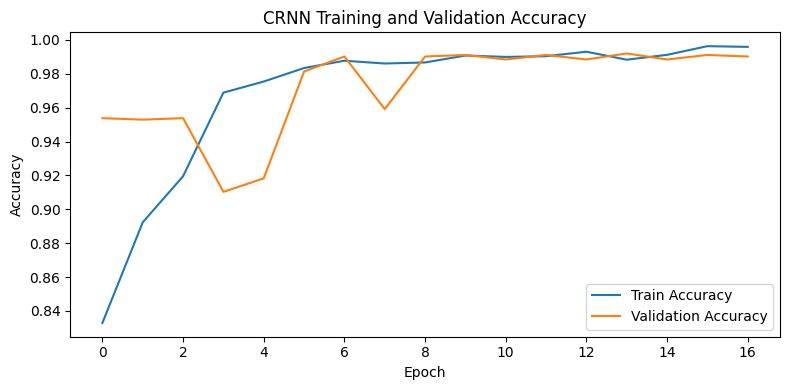

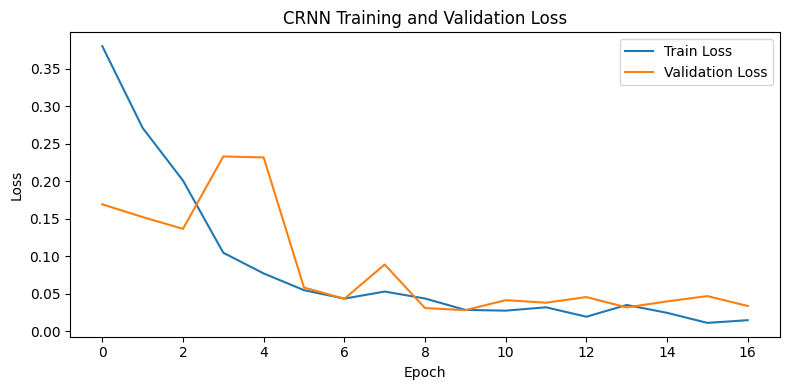

              precision    recall  f1-score   support

    non_wasp       0.99      0.99      0.99       645
        wasp       0.99      0.99      0.99       481

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



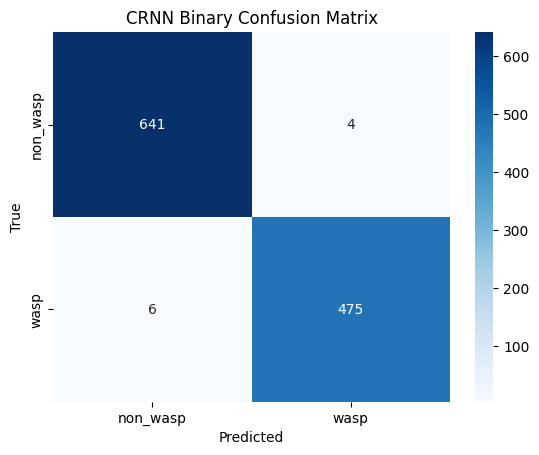

{'Model': 'CRNN', 'Accuracy': 0.9911190053285968, 'Precision': 0.9911878494932449, 'Recall': 0.9906622185691953, 'Macro F1': 0.990921697626419, 'Wasp Recall': 0.9875259875259875, 'Wasp Precision': 0.9916492693110647, 'False Negative': 6, 'False Positive': 4, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.006201550387596899}


In [34]:
'''
CRNN Validation 평가
'''

# 클래스 별 확률 예측
crnn_val_pred_probs = crnn_model.predict(X_val_crnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
crnn_val_pred_classes = predict_classes(crnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(crnn_history, 'CRNN')

crnn_val_result = evaluate_model(y_val_mel, crnn_val_pred_classes, 'CRNN')

# 5. Machine Learning

## 5-1. Feature 추출

오디오 파일에서 전통적인 머신러닝 모델이 사용할 수 있도록 고정 길이의 음향 특징을 추출한다.

사용 특징:
- MFCC
- Chroma
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff
- Zero Crossing Rate
- RMS

In [35]:
# ML 특징은 Mel 특징과 동일한 파형으로 이미 생성했습니다.


In [36]:
print('ML features:', X_ml.shape, 'labels:', y_ml.shape)

ML features: (7115, 74) labels: (7115,)


In [37]:
# DL과 정확히 같은 source 분할 사용
X_train_ml, X_val_ml, X_test_ml = [X_ml[i].copy() for i in (train_indices, val_indices, test_indices)]
y_train_ml, y_val_ml, y_test_ml = [y_ml[i] for i in (train_indices, val_indices, test_indices)]
# 혼합 없이 DL과 동일한 원본 Train 분할을 사용합니다.
np.testing.assert_array_equal(X_val_ml, X_ml[val_indices])
np.testing.assert_array_equal(X_test_ml, X_ml[test_indices])
assert len(X_train_ml) == len(X_train_mel)
assert np.array_equal(y_train_ml, y_train_mel), 'DL/ML 학습 라벨이 일치해야 합니다.'
ml_sample_weights = compute_sample_weight('balanced', y_train_ml)

## 5-2. Random Forest

- RandomForest
> 여러 개의 Decision Tree를 구성하고, 각 Tree의 예측 결과를 종합하여 최종 클래스를 결정하는 앙상블 기반 머신러닝 모델.

In [38]:
'''
RF 분류 모델 학습
'''

rf_model = RandomForestClassifier(n_estimators = 200, random_state = SEED, n_jobs = -1, class_weight = 'balanced')

rf_model.fit(X_train_ml, y_train_ml)

print('RandomForest 학습 완료')

RandomForest 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.99      1.00      0.99       645
        wasp       1.00      0.99      0.99       481

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



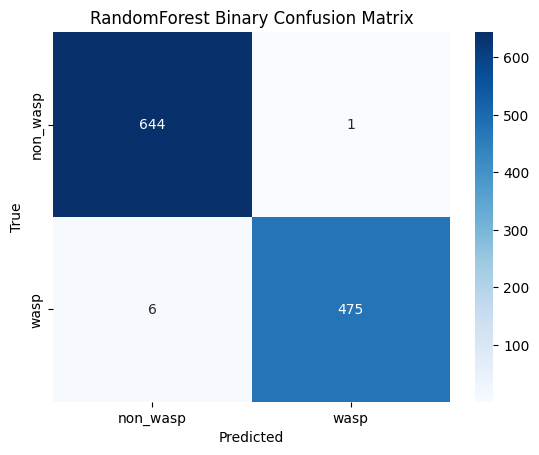

{'Model': 'RandomForest', 'Accuracy': 0.9937833037300178, 'Precision': 0.9943341952165481, 'Recall': 0.9929877999645442, 'Macro F1': 0.9936400350193454, 'Wasp Recall': 0.9875259875259875, 'Wasp Precision': 0.9978991596638656, 'False Negative': 6, 'False Positive': 1, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.0015503875968992248}


In [39]:
'''
RandomForest Validation 평가
'''

# 예측
rf_val_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_val_ml), WASP_THRESHOLD)

rf_val_result = evaluate_model(y_val_ml, rf_val_pred_classes, 'RandomForest')

## 5-3. LightGBM

- Light GBM
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러개의 Decision Tree를 순차적으로 학습하면서 이전 Tree의 오차를 보완하는 방식으로 성능을 개선

In [40]:
'''
LightGBM 분류 모델 학습
'''

lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    random_state = SEED,
    verbosity = -1,
    objective = 'binary'
)

lgbm_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('LightGBM 학습 완료')

LightGBM 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.99      1.00      0.99       645
        wasp       1.00      0.99      0.99       481

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



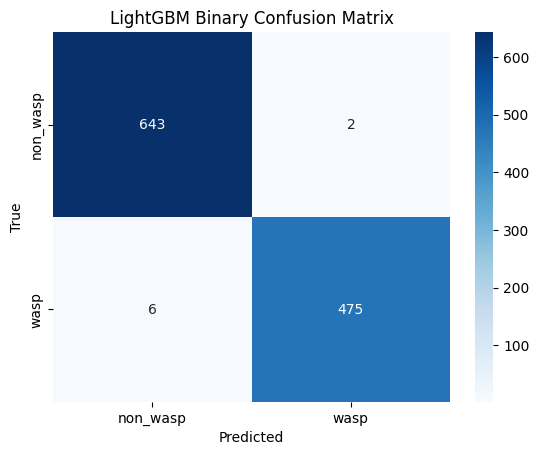

{'Model': 'LightGBM', 'Accuracy': 0.9928952042628775, 'Precision': 0.9932810677933799, 'Recall': 0.9922126061660945, 'Macro F1': 0.9927334445473407, 'Wasp Recall': 0.9875259875259875, 'Wasp Precision': 0.9958071278825996, 'False Negative': 6, 'False Positive': 2, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.0031007751937984496}


In [41]:
'''
LightGBM Validation 평가
'''

lgbm_val_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_val_ml), WASP_THRESHOLD)

lgbm_val_result = evaluate_model(y_val_ml, lgbm_val_pred_classes, 'LightGBM')

## 5-4. XGBoost

- XGBoost
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러 개의 Decision Tree를 순차적으로 학습하면서 이전 모델의 오차를 보완하는 방식으로 성능을 개선

In [42]:
'''
XGBoost 분류 모델 학습
'''

xgb_model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = SEED,
    objective = 'binary:logistic',
    eval_metric = 'logloss'
)

xgb_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('XGBoost 학습 완료')

XGBoost 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.98      1.00      0.99       645
        wasp       1.00      0.98      0.99       481

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



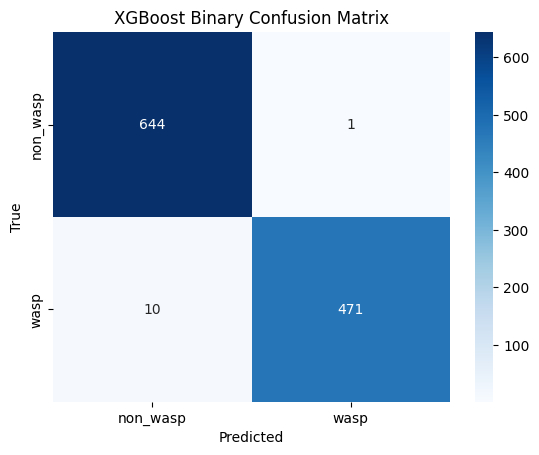

{'Model': 'XGBoost', 'Accuracy': 0.9902309058614565, 'Precision': 0.9912954180272637, 'Recall': 0.98882979580654, 'Macro F1': 0.9899947251376675, 'Wasp Recall': 0.9792099792099792, 'Wasp Precision': 0.9978813559322034, 'False Negative': 10, 'False Positive': 1, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.0015503875968992248}


In [43]:
'''
XGBoost Validation 평가
'''

xgb_val_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_val_ml), WASP_THRESHOLD)

xgb_val_result = evaluate_model(y_val_ml, xgb_val_pred_classes, 'XGBoost')

## 5-5. Machine Learning 모델 저장

In [44]:
ensure_directory_exists(MODEL_DIR)

RF_MODEL_PATH = os.path.join(MODEL_DIR, 'randomforest.pkl')
LGBM_MODEL_PATH = os.path.join(MODEL_DIR, 'lightgbm.pkl')
XGB_MODEL_PATH = os.path.join(MODEL_DIR, 'xgboost.pkl')

joblib.dump(rf_model, RF_MODEL_PATH)
joblib.dump(lgbm_model, LGBM_MODEL_PATH)
joblib.dump(xgb_model, XGB_MODEL_PATH)

print('===== Machine Learning 모델 저장 완료 =====')
print('RandomForest : ', RF_MODEL_PATH)
print('LightGBM     : ', LGBM_MODEL_PATH)
print('XGBoost      : ', XGB_MODEL_PATH)

===== Machine Learning 모델 저장 완료 =====
RandomForest :  C:\Users\gold4\Desktop\Buzz\ai_model\models\randomforest.pkl
LightGBM     :  C:\Users\gold4\Desktop\Buzz\ai_model\models\lightgbm.pkl
XGBoost      :  C:\Users\gold4\Desktop\Buzz\ai_model\models\xgboost.pkl


# 6. 모델 성능 비교 및 최종 추론 방식 선정

학습한 모델들의 Validation 성능을 동일한 평가 지표로 비교

- Accuracy
- Precision
- Recall
- Macro F1
- Wasp Recall

Validation 결과를 기준으로 Best Single Model을 선정하고, 이후 Ensemble 방식과 비교하여 최종 추론 방식을 결정

In [45]:
'''
Validation 기준 모델 성능 비교
'''

validation_results = pd.DataFrame([
    cnn_val_result,
    mobilenet_val_result,
    crnn_val_result,
    rf_val_result,
    lgbm_val_result,
    xgb_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준으로 정렬
validation_results = validation_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Validation 모델 성능 비교 =====')
display(validation_results)

# Best Single Model 선정
best_model_name = validation_results.loc[0, 'Model']

print('===== Best Single Model =====')
print(best_model_name)

===== Validation 모델 성능 비교 =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,Wasp Support,Non Wasp Support,False Positive Rate
0,CNN,0.996448,0.996117,0.996635,0.996373,0.997921,0.993789,1,3,481,645,0.004651
1,MobileNetV2,0.992895,0.992741,0.992741,0.992741,0.991684,0.991684,4,4,481,645,0.006202
2,RandomForest,0.993783,0.994334,0.992988,0.993640,0.987526,0.997899,6,1,481,645,0.001550
3,LightGBM,0.992895,0.993281,0.992213,0.992733,0.987526,0.995807,6,2,481,645,0.003101
4,CRNN,0.991119,0.991188,0.990662,0.990922,0.987526,0.991649,6,4,481,645,0.006202
5,XGBoost,0.990231,0.991295,0.988830,0.989995,0.979210,0.997881,10,1,481,645,0.001550


===== Best Single Model =====
CNN


              precision    recall  f1-score   support

    non_wasp       1.00      1.00      1.00       645
        wasp       1.00      0.99      1.00       481

    accuracy                           1.00      1126
   macro avg       1.00      1.00      1.00      1126
weighted avg       1.00      1.00      1.00      1126



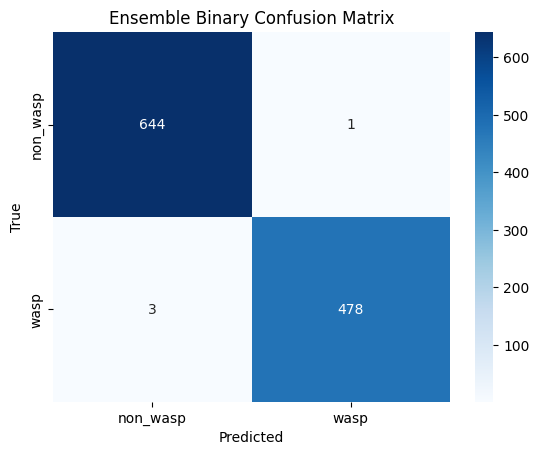

{'Model': 'Ensemble', 'Accuracy': 0.9964476021314387, 'Precision': 0.9966377660827394, 'Recall': 0.9961063030830473, 'Macro F1': 0.9963686790505676, 'Wasp Recall': 0.9937629937629938, 'Wasp Precision': 0.9979123173277662, 'False Negative': 3, 'False Positive': 1, 'Wasp Support': 481, 'Non Wasp Support': 645, 'False Positive Rate': 0.0015503875968992248}


In [46]:
'''
Soft Voting Ensemble Validation 평가

6개 모델의 클래스별 예측 확률을 평균하여 최종 클래스를 결정
'''

# Machine Learning 모델의 Validation 예측 확률
rf_val_pred_probs = ordered_ml_probabilities(rf_model, X_val_ml)
lgbm_val_pred_probs = ordered_ml_probabilities(lgbm_model, X_val_ml)
xgb_val_pred_probs = ordered_ml_probabilities(xgb_model, X_val_ml)

# Deep Learning + Machine Learning 6개 모델의 확률 평균
ensemble_val_pred_probs = np.mean([
    cnn_val_pred_probs,
    mobilenet_val_pred_probs,
    crnn_val_pred_probs,
    rf_val_pred_probs,
    lgbm_val_pred_probs,
    xgb_val_pred_probs
], axis = 0)

# 평균 말벌 확률에 공통 임계값 적용
ensemble_val_pred_classes = predict_classes(ensemble_val_pred_probs, WASP_THRESHOLD)

# Ensemble Validation 성능 평가
ensemble_val_result = evaluate_model(y_val_mel, ensemble_val_pred_classes, 'Ensemble')

===== Best Single Model vs Ensemble =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,Wasp Support,Non Wasp Support,False Positive Rate
0,CNN,0.996448,0.996117,0.996635,0.996373,0.997921,0.993789,1,3,481,645,0.004651
1,Ensemble,0.996448,0.996638,0.996106,0.996369,0.993763,0.997912,3,1,481,645,0.001550


===== 최종 추론 방식 =====
Best Single Model : CNN


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,Wasp Support,Non Wasp Support,False Positive Rate,False Negative Rate
0,CNN,0.996448,0.996117,0.996635,0.996373,0.997921,0.993789,1,3,481,645,0.004651,0.002079
1,MobileNetV2,0.992895,0.992741,0.992741,0.992741,0.991684,0.991684,4,4,481,645,0.006202,0.008316
2,RandomForest,0.993783,0.994334,0.992988,0.993640,0.987526,0.997899,6,1,481,645,0.001550,0.012474
3,LightGBM,0.992895,0.993281,0.992213,0.992733,0.987526,0.995807,6,2,481,645,0.003101,0.012474
4,CRNN,0.991119,0.991188,0.990662,0.990922,0.987526,0.991649,6,4,481,645,0.006202,0.012474
5,XGBoost,0.990231,0.991295,0.988830,0.989995,0.979210,0.997881,10,1,481,645,0.001550,0.020790


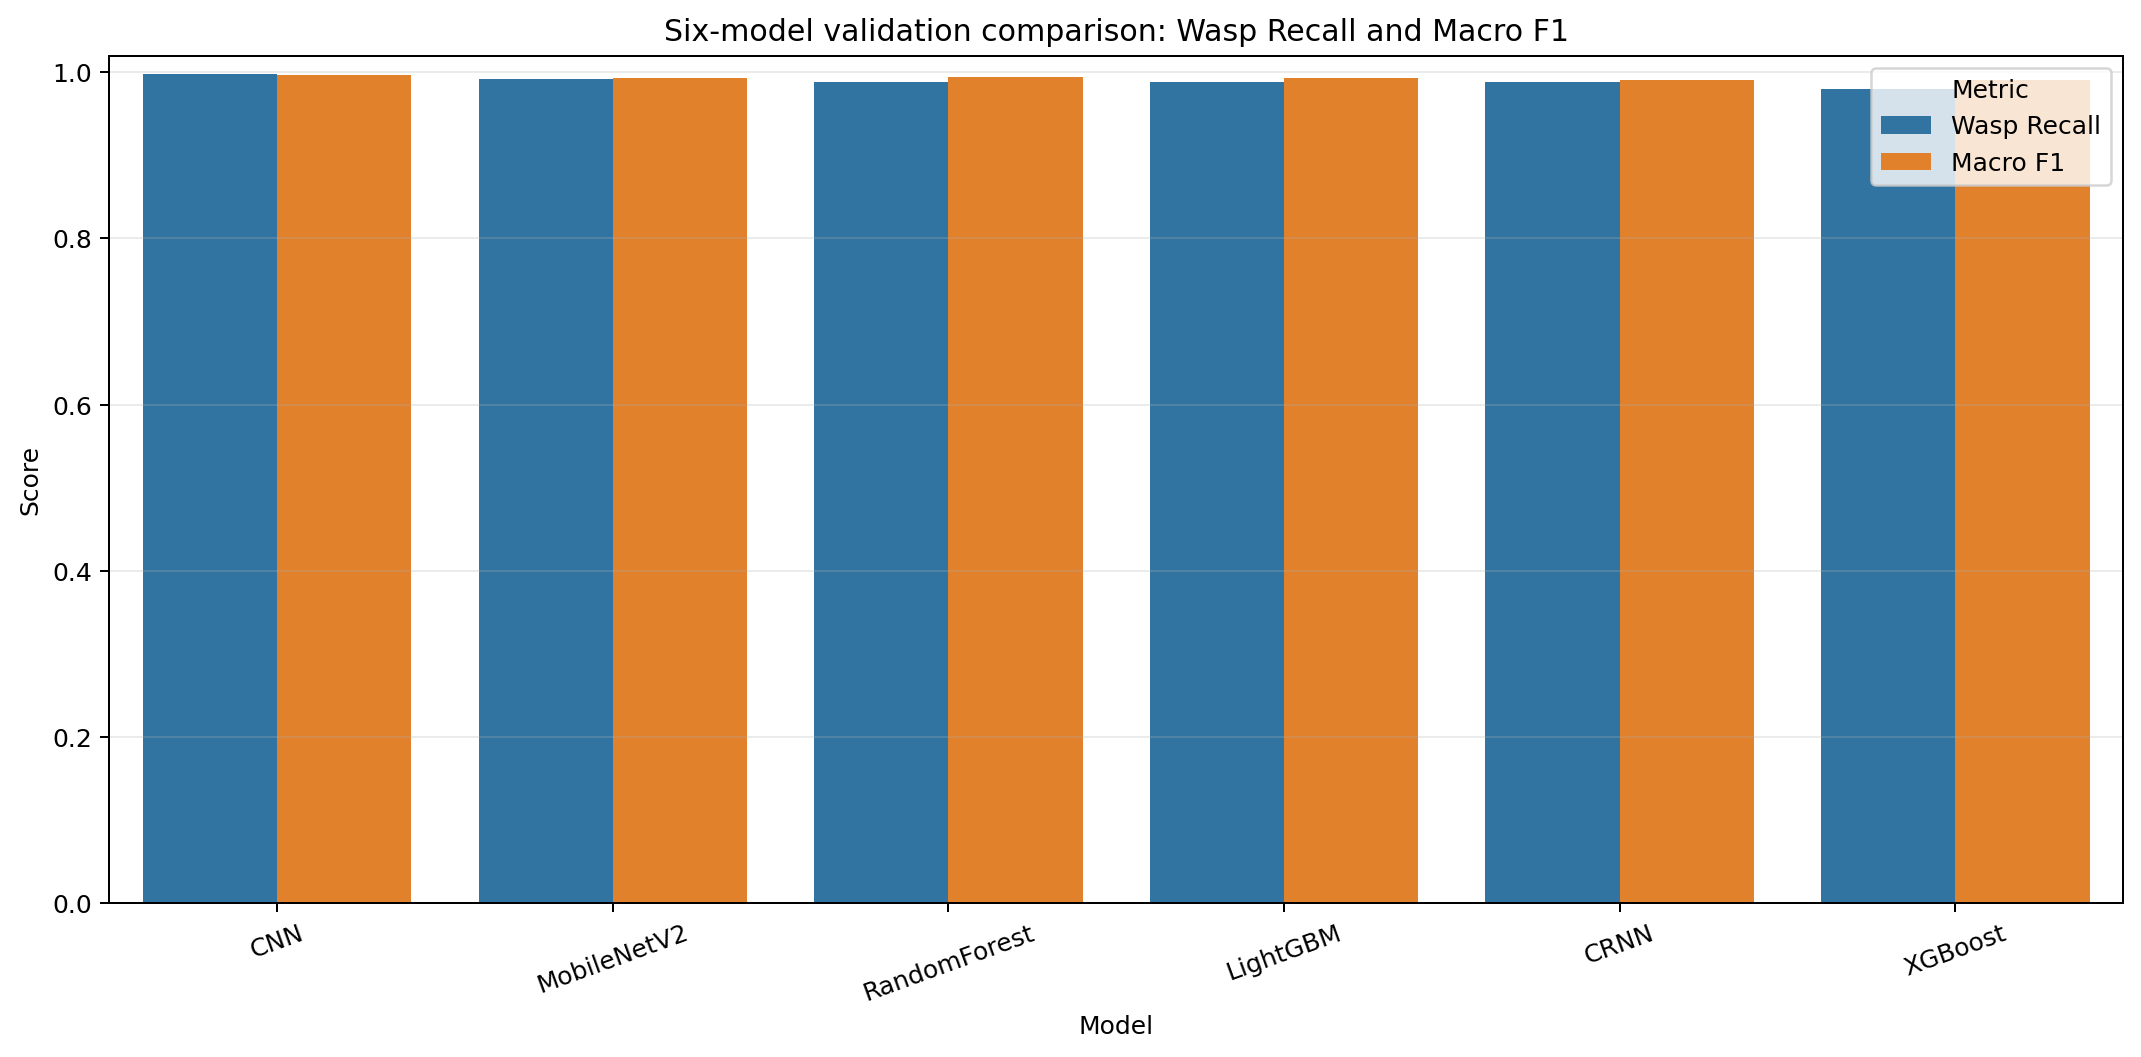

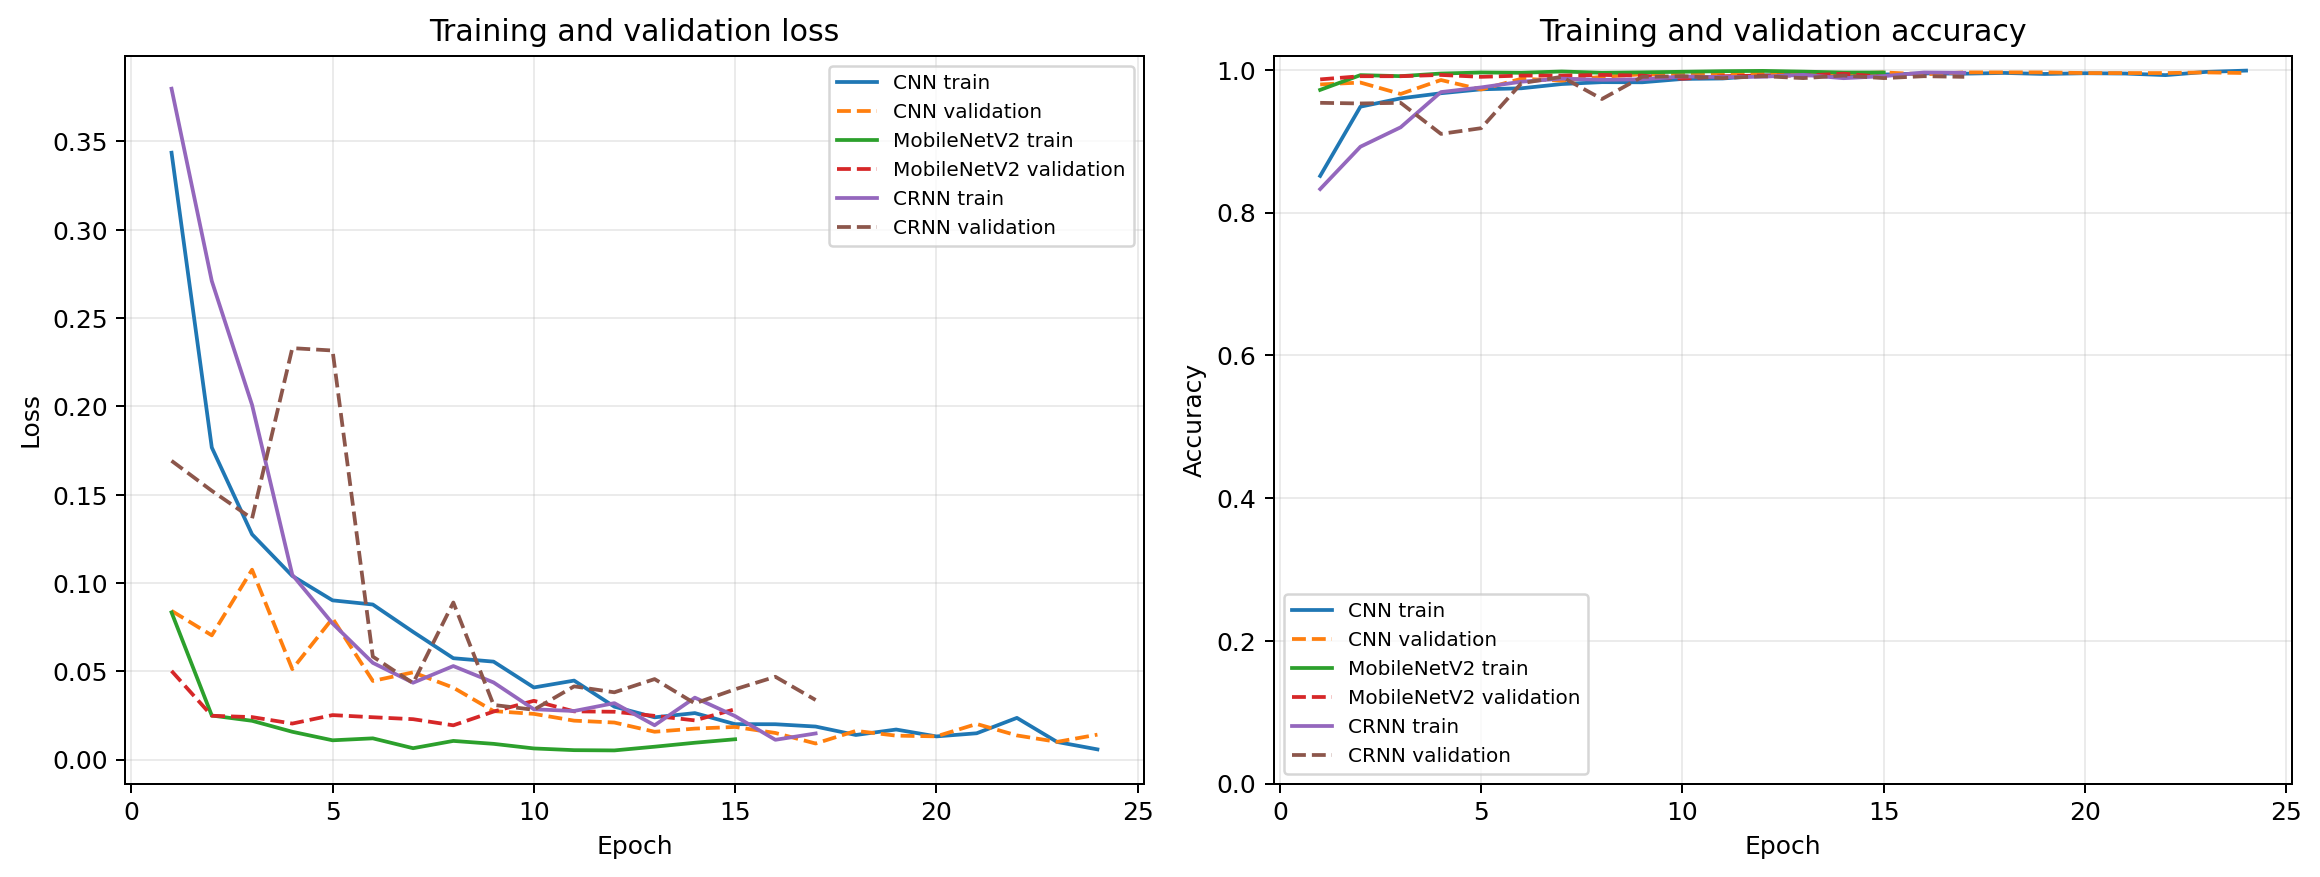

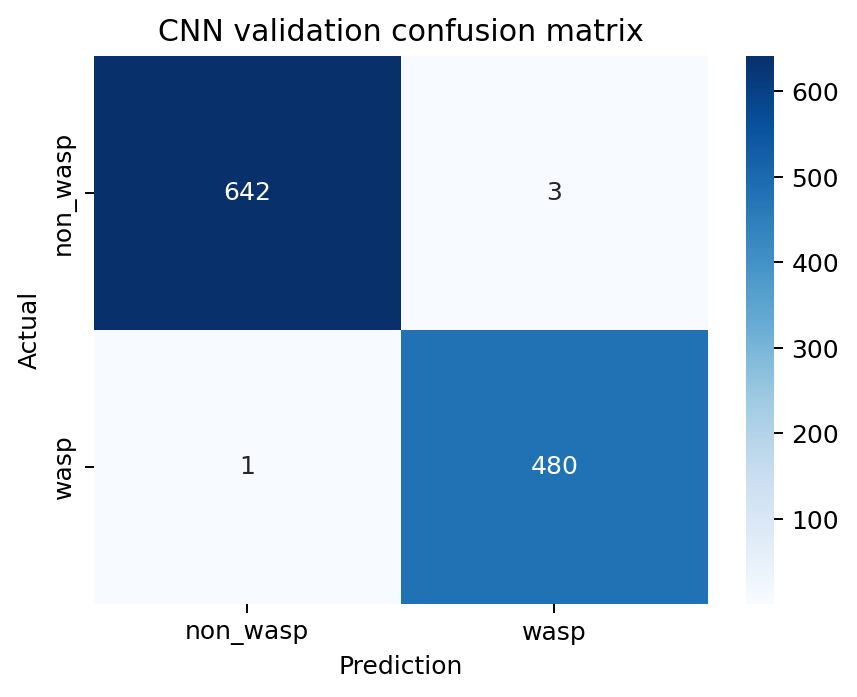

비교 리포트 저장 완료: C:\Users\gold4\Desktop\Buzz\ai_model\models


In [47]:
'''
Best Single Model vs Ensemble 비교

Validation 성능을 기준으로 최종 추론 방식 결정
'''

# Best Single Model 결과
best_single_result = validation_results.iloc[0].to_dict()

# 비교용 DataFrame
final_method_results = pd.DataFrame([
    best_single_result,
    ensemble_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준
final_method_results = final_method_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Best Single Model vs Ensemble =====')
display(final_method_results)

# 최종 추론 방식 결정
final_method_name = final_method_results.loc[0, 'Model']

if final_method_name == 'Ensemble':
    final_inference_type = 'ensemble'
    final_model_name = None
else:
    final_inference_type = 'single'
    final_model_name = final_method_name

print('===== 최종 추론 방식 =====')
if final_inference_type == 'ensemble':
    print('Ensemble')
else:
    print(f'Best Single Model : {final_model_name}')

# 다음 재학습부터 비교 그래프와 원본별 감사 자료를 자동 저장합니다.
# 비교 그래프는 6개 단일 모델의 Wasp Recall과 Macro F1만 표시합니다.
validation_report = save_validation_report(validation_results, MODEL_DIR)
save_training_histories({
    'CNN': cnn_history, 'MobileNetV2': mobilenet_history, 'CRNN': crnn_history
}, MODEL_DIR)
validation_probabilities = {
    'CNN': cnn_val_pred_probs,
    'MobileNetV2': mobilenet_val_pred_probs,
    'CRNN': crnn_val_pred_probs,
    'RandomForest': rf_val_pred_probs,
    'LightGBM': lgbm_val_pred_probs,
    'XGBoost': xgb_val_pred_probs,
    'Ensemble': ensemble_val_pred_probs,
}
validation_prediction_report = save_prediction_manifest(
    paths_val_mel, source_ids[val_indices], y_val_mel,
    validation_probabilities, 'validation', MODEL_DIR
)
save_source_report(
    validation_prediction_report, final_method_name, WASP_THRESHOLD, MODEL_DIR
)
from IPython.display import Image as NotebookImage
display(validation_report)
display(NotebookImage(filename=str(MODEL_DIR / 'validation_model_comparison.png')))
display(NotebookImage(filename=str(MODEL_DIR / 'deep_learning_histories.png')))
# 최종 선정 방식의 Validation confusion matrix를 저장하고 바로 표시합니다.
final_validation_pred_classes = predict_classes(
    validation_probabilities[final_method_name], WASP_THRESHOLD
)
save_confusion_matrix(
    y_val_mel, final_validation_pred_classes, final_method_name, 'validation', MODEL_DIR
)
display(NotebookImage(filename=str(
    MODEL_DIR / f'validation_{final_method_name.lower()}_confusion_matrix.png'
)))
print('비교 리포트 저장 완료:', MODEL_DIR)

              precision    recall  f1-score   support

    non_wasp       1.00      1.00      1.00       612
        wasp       1.00      1.00      1.00       492

    accuracy                           1.00      1104
   macro avg       1.00      1.00      1.00      1104
weighted avg       1.00      1.00      1.00      1104



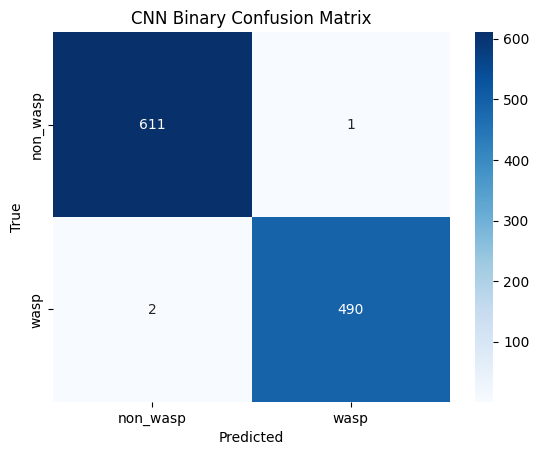

{'Model': 'CNN', 'Accuracy': 0.9972826086956522, 'Precision': 0.9973503486907898, 'Recall': 0.9971504862107445, 'Macro F1': 0.9972495692071335, 'Wasp Recall': 0.9959349593495935, 'Wasp Precision': 0.9979633401221996, 'False Negative': 2, 'False Positive': 1, 'Wasp Support': 492, 'Non Wasp Support': 612, 'False Positive Rate': 0.0016339869281045752}
===== 최종 Test 결과 =====
최종 추론 방식 : CNN


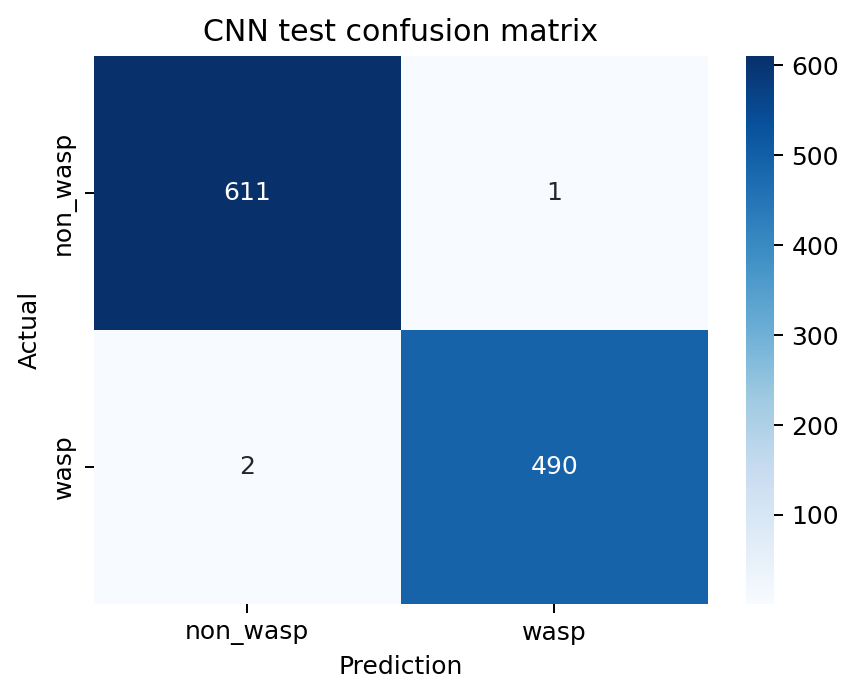

In [48]:
'''
최종 추론 방식 Test 평가

Validation에서 결정된 최종 추론 방식을 Test 데이터로 마지막 한 번 더 평가
'''

if final_inference_type == 'ensemble':
    # Deep Learning 모델 Test 예측 확률
    cnn_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
    mobilenet_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
    crnn_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)

    # Machine Learning 모델 Test 예측 확률
    rf_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
    lgbm_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
    xgb_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)

    # Soft Voting
    final_test_pred_probs = np.mean([
        cnn_test_pred_probs,
        mobilenet_test_pred_probs,
        crnn_test_pred_probs,
        rf_test_pred_probs,
        lgbm_test_pred_probs,
        xgb_test_pred_probs
    ], axis = 0)

    final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)

    final_test_name = 'Ensemble'
else:
    if final_model_name == 'CNN':
        final_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'MobileNetV2':
        final_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'CRNN':
        final_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'RandomForest':
        final_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'LightGBM':
        final_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'XGBoost':
        final_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_test_ml), WASP_THRESHOLD)
    else:
        raise ValueError(f'지원하지 않는 모델입니다: {final_model_name}')

    final_test_name = final_model_name

# 최종 Test 평가
final_test_result = evaluate_model(y_test_mel, final_test_pred_classes, final_test_name)

print('===== 최종 Test 결과 =====')
print(f'최종 추론 방식 : {final_test_name}')

# Test는 Validation에서 고른 최종 방식만 기록합니다.
test_prediction_report = save_prediction_manifest(
    paths_test_mel, source_ids[test_indices], y_test_mel,
    {final_test_name: final_test_pred_probs}, 'test', MODEL_DIR
)
save_source_report(test_prediction_report, final_test_name, WASP_THRESHOLD, MODEL_DIR)
save_confusion_matrix(
    y_test_mel, final_test_pred_classes, final_test_name, 'test', MODEL_DIR
)
display(NotebookImage(filename=str(
    MODEL_DIR / f'test_{final_test_name.lower()}_confusion_matrix.png'
)))

import json
with (MODEL_DIR / 'training_summary.json').open('w', encoding='utf-8') as handle:
    json.dump({
        'classes': CLASSES, 'sampleRate': SR, 'duration': DURATION,
        'waspThreshold': WASP_THRESHOLD, 'seed': SEED,
        'inferenceType': final_inference_type, 'modelName': final_model_name,
        'validationSelection': final_method_results.to_dict(orient='records'),
        'testMetrics': final_test_result,
        'reportArtifacts': [
            'validation_model_metrics.csv', 'validation_model_metrics.json',
            'validation_model_comparison.png',
            f'validation_{final_method_name.lower()}_confusion_matrix.png',
            'deep_learning_histories.png', 'deep_learning_histories.json',
            'validation_predictions.csv', 'test_predictions.csv',
        ],
        'augmentation': {'enabled': False, 'mode': 'original_only'},
    }, handle, ensure_ascii=False, indent=2)

# 7. 최종 추론 및 UI 데이터 생성

임의의 WAV 파일 하나를 입력받아 모델 예측 결과와
UI 시각화에 필요한 Waveform, FFT, Spectrogram 데이터를 생성한다.

반환 데이터:
- 예측 클래스
- 예측 확률
- 클래스별 확률
- Waveform
- FFT
- Mel-Spectrogram

In [49]:
from src.visualization import create_audio_visualization_data
# 그래프도 src의 공통 구현을 사용한다.


In [50]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [51]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [52]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [53]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [54]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [55]:
from src.inference import analyze_audio as analyze_binary_audio

trained_models = {
    'CNN': cnn_model, 'MobileNetV2': mobilenet_model, 'CRNN': crnn_model,
    'RandomForest': rf_model, 'LightGBM': lgbm_model, 'XGBoost': xgb_model,
}

def analyze_audio(audio_path, offset=0.0):
    return analyze_binary_audio(
        audio_path, trained_models, final_inference_type, final_model_name,
        threshold=WASP_THRESHOLD, offset=offset,
    )

In [56]:
# 최종 Test 중 한 구간의 실제 파형/이진 확률 확인
# 별도 시연 음원은 경로를 바꾸고 offset(초)을 지정한다.
test_audio_path = str(paths_test_mel[0])
result = analyze_audio(test_audio_path)
print('파일:', test_audio_path)
print('모델:', result['meta']['modelName'])
print('판정:', result['prediction']['label'])
print('확률:', result['prediction']['probabilities'])
print('말벌 임계값:', result['meta']['waspThreshold'])

파일: C:\Users\gold4\Desktop\Buzz\ai_model\audio\non_wasp\01_1_SW_20221116\clip_0000.wav
모델: CNN
판정: non_wasp
확률: {'non_wasp': 0.9974637031555176, 'wasp': 0.002536261919885874}
말벌 임계값: 0.5
